# 9 ResNet

**ResNet (2015):** $\quad$ Microsoft CNN that introduces **residual connections** to train very deep models

<div align="center">
<table><tr>
<td align="center" style="border: none;"><img src="Figure_14.21.png" width=150/></td>
<td align="center" style="border: none;" width=50></td>
<td align="center" style="border: none;"><img src="Figure_14.20.png" width=600/></td>
</tr>
</table>
</div>


<p style="page-break-after:always;"></p>


[**ResNet (2015):**](https://huggingface.co/docs/timm/models/resnet) $\;$ [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385)

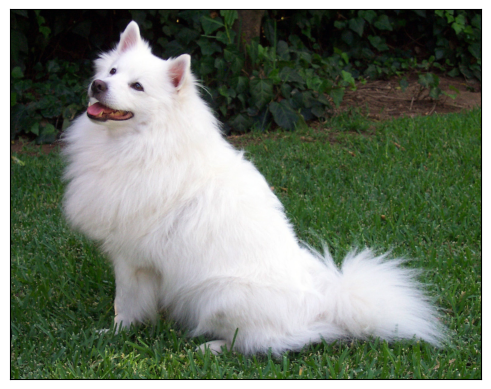

In [1]:
import matplotlib.pyplot as plt; import urllib; from PIL import Image; import torch
import timm; from timm.data import resolve_data_config; from timm.data.transforms_factory import create_transform
model = timm.create_model('resnet18', pretrained=True); model.eval()
config = resolve_data_config({}, model=model); transform = create_transform(**config)
url, file = ("https://github.com/pytorch/hub/raw/master/images/dog.jpg", "dog.jpg")
urllib.request.urlretrieve(url, file); img = Image.open(file).convert('RGB')
tensor = transform(img).unsqueeze(0); plt.xticks([]); plt.yticks([]); plt.imshow(img);

In [2]:
probs = torch.nn.functional.softmax(model(tensor)[0], dim=0)
url, file = ("https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt", "imagenet_classes.txt")
urllib.request.urlretrieve(url, file); cats = [s.strip() for s in open("imagenet_classes.txt", "r").readlines()]
i = probs.argmax().item(); print(f'{cats[i]} {probs[i].item():.2%} ')

Samoyed 99.96% 
